## 1. O problema: *Random Walk* 

O valor verdadeiro de cada estado sob a política aleatória é
$$V^\pi(k) = \frac{k}{6}, \qquad k = 1,\dots,5,$$
ou seja `1/6, 2/6, 3/6, 4/6, 5/6`. Vamos ver o MC reproduzir esses números.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ---- Ambiente Random Walk ----
N_STATES = 7          
LEFT, RIGHT = 0, 1
START = 3
GAMMA = 1.0

def step(state, action):
    nxt = state - 1 if action == LEFT else state + 1
    if nxt == 6:                    
        return nxt, 1.0, True
    if nxt == 0:                     
        return nxt, 0.0, True
    return nxt, 0.0, False


In [2]:
# ---- Gera um episodio seguindo a politica aleatoria 
def generate_episode():
    states, actions, rewards = [], [], []
    s = START
    done = False
    while not done:
        a = LEFT if np.random.rand() < 0.5 else RIGHT   # politica pi
        s2, r, done = step(s, a)
        states.append(s); actions.append(a); rewards.append(r)
        s = s2
    return states, actions, rewards

print(generate_episode())


([3, 4, 5], [1, 1, 1], [0.0, 0.0, 1.0])


### First-Visit Monte Carlo 

Percorremos o episódio de trás para frente acumulando o retorno $G$. Na **primeira visita** de cada estado
dentro do episódio, adicionamos $G$ à soma daquele estado e atualizamos a média. 


In [3]:
TRUE_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])   # valores verdadeiros 

def first_visit_mc(num_episodes, gamma=GAMMA):
    V            = np.zeros(N_STATES)
    returns_sum  = np.zeros(N_STATES)
    visit_count  = np.zeros(N_STATES)
    rms_hist     = []

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode()
        G = 0.0
        T = len(states)
        for t in reversed(range(T)):
            G = gamma * G + rewards[t]      # rewards[t] = R_{t+1}
            s = states[t]
            if s not in states[:t]:         # <-- criterio de primeira visita
                returns_sum[s] += G
                visit_count[s] += 1
                V[s] = returns_sum[s] / visit_count[s]   # media dos retornos
        rms_hist.append(np.sqrt(np.mean((V[1:6] - TRUE_V[1:6])**2)))

    return V, rms_hist


In [4]:
np.random.seed(0)
V, rms_hist = first_visit_mc(num_episodes=5000)

print("estado |   MC   | verdadeiro")
for s in range(1, 6):
    print(f"   {s}   | {V[s]:.3f} |   {TRUE_V[s]:.3f}")


estado |   MC   | verdadeiro
   1   | 0.161 |   0.167
   2   | 0.339 |   0.333
   3   | 0.494 |   0.500
   4   | 0.651 |   0.667
   5   | 0.824 |   0.833


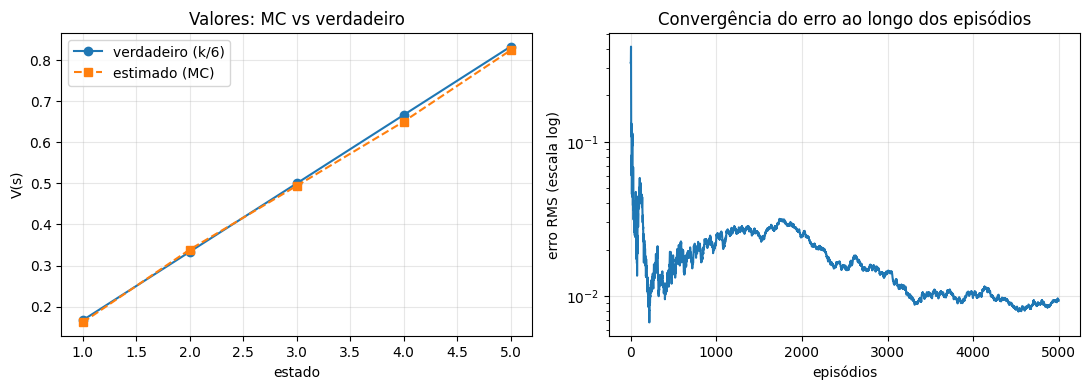

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(range(1, 6), TRUE_V[1:6], 'o-', label='verdadeiro (k/6)')
ax[0].plot(range(1, 6), V[1:6],      's--', label='estimado (MC)')
ax[0].set_xlabel('estado'); ax[0].set_ylabel('V(s)')
ax[0].set_title('Valores: MC vs verdadeiro'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(rms_hist)
ax[1].set_xlabel('episódios'); ax[1].set_ylabel('erro RMS (escala log)')
ax[1].set_yscale('log')
ax[1].set_title('Convergência do erro ao longo dos episódios'); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()
